<a href="https://colab.research.google.com/github/ExTc-aShiSh/Introduction-to-AI/blob/main/8_queen_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Solution found for 8-Queens:


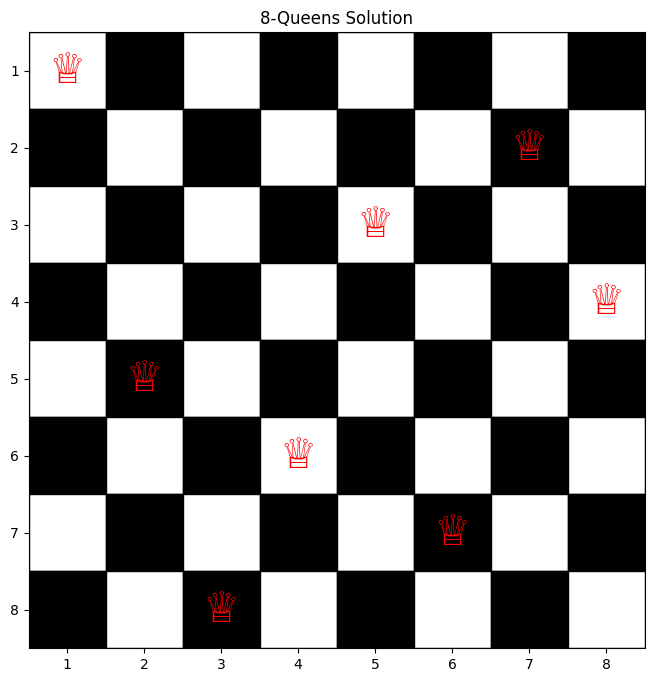

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_n_queens(board):
    n = len(board)
    if n == 0: # Handle empty board case gracefully
        print("Empty board provided, nothing to visualize.")
        return

    fig, ax = plt.subplots(figsize=(n, n))

    # Draw the chessboard
    for i in range(n):
        for j in range(n):
            color = 'white' if (i + j) % 2 == 0 else 'black'
            ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color, edgecolor='black'))

    # Place queens
    for r in range(n):
        for c in range(n):
            if board[r][c] == 1:
                ax.text(c + 0.5, r + 0.5, '♕', fontsize=30, ha='center', va='center', color='red')

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_xticks(np.arange(n) + 0.5, labels=[str(i+1) for i in range(n)])
    ax.set_yticks(np.arange(n) + 0.5, labels=[str(i+1) for i in range(n)])
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'{n}-Queens Solution')
    plt.gca().invert_yaxis() # Invert y-axis to match typical board representation (row 0 at top)
    plt.show()

def solve_n_queens(n):
    board = [[0 for _ in range(n)] for _ in range(n)]
    solutions = []

    def is_safe(board, row, col):
        # Check row on left side
        for i in range(col):
            if board[row][i] == 1:
                return False
        # Check upper diagonal on left side
        for i, j in zip(range(row, -1, -1), range(col, -1, -1)):
            if board[i][j] == 1:
                return False
        # Check lower diagonal on left side
        for i, j in zip(range(row, n, 1), range(col, -1, -1)):
            if board[i][j] == 1:
                return False
        return True

    def solve_util(board, col):
        if col >= n:
            solutions.append([row[:] for row in board])
            return True

        res = False
        for i in range(n):
            if is_safe(board, i, col):
                board[i][col] = 1
                res = solve_util(board, col + 1) or res
                board[i][col] = 0 # backtrack
        return res

    solve_util(board, 0)
    return solutions[0] if solutions else None

# Get the solved board for 8-Queens problem
solved_board = solve_n_queens(8)

if solved_board:
    print("Solution found for 8-Queens:")
    visualize_n_queens(solved_board)
else:
    print("No solution exists for 8-Queens problem.")